# Categorical Data Encoding Techniques in Machine Learning

### A teaching notebook on Label, One-Hot, Ordinal, Binary, Target, and Frequency encoding

Most machine learning algorithms operate on numerical matrices, yet real datasets are full of
categorical features — city names, education levels, product colours. Converting these into
numbers without introducing spurious structure is called **categorical encoding**, and the
choice of technique can swing model accuracy by tens of percentage points. This notebook works
through six major encoding methods mathematically, then encodes a real toy dataset with each one
and measures their actual downstream effect on model accuracy.

**Roadmap**

1. Why naive numeric mappings are dangerous
2. Six encoding methods: definitions and worked examples
3. Binary encoding — bridging Label and One-Hot
4. Target encoding and the smoothing formula
5. Dimensionality growth: One-Hot vs. Binary vs. everything else
6. An experimental benchmark: encoding choice vs. model accuracy
7. A practical decision framework


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Why Encoding Matters

Encoding methods differ along three axes that determine whether they are appropriate for a given
feature: (1) whether they impose an ordinal ordering on otherwise unordered categories, (2) how
many new columns they introduce, and (3) whether they use the target variable (which brings
predictive power but also overfitting risk). Choosing the wrong encoding can mislead linear
models into learning a false numeric relationship, or explode the feature matrix into thousands of
columns.


## 2. Six Encoding Methods

**Label encoding.** Assigns a unique integer to each category in a single column:
$f(c_i) = i-1$. Extremely memory-efficient and compatible with tree-based models (which split on
thresholds and are unaffected by the implied order), but dangerous for linear models on nominal
data, since it implies a false ordinal relationship — e.g. it would let a model "learn" that
$\text{Berlin}(2) > \text{Cairo}(0)$, which is meaningless.

**One-Hot encoding.** Creates $n$ binary columns for $n$ categories:
$\text{OHE}(c_i)_j = 1$ if $i=j$, else $0$. No ordinal assumption, fully compatible with linear
models and neural networks — but dimensionality grows linearly with cardinality, and the columns
are collinear (the "dummy variable trap"), which is why one column is often dropped.

**Ordinal encoding.** Appropriate only when categories have a genuine, domain-defined natural
order, e.g. `No Education < High School < Bachelor < Master < PhD`. Unlike label encoding, the
mapping is *meaningful*, not arbitrary.

**Binary encoding.** A hybrid: label-encode first, convert the integer to binary, then split the
bits into separate columns. For $n$ categories, only $k=\lceil\log_2(n+1)\rceil$ columns are
needed — for $n=1000$, just 10 columns instead of 1000.

**Target (mean) encoding.** Replaces each category with the mean of the target variable for that
category:

$$
\text{TE}(c_i) = \mathbb{E}[Y \mid X=c_i] = \frac{1}{n_i}\sum_{j: x_j = c_i} y_j
$$

To avoid unstable estimates for rare categories, the raw mean is blended with the global mean:

$$
\text{TE}_{\text{smooth}}(c_i) = \lambda_i \cdot \text{mean}(Y\mid c_i) + (1-\lambda_i)\cdot \text{mean}(Y),
\qquad \lambda_i = \frac{n_i}{n_i + m}
$$

As $n_i \to \infty$, $\lambda_i \to 1$ (trust the category mean); as $n_i \to 0$, $\lambda_i \to 0$
(fall back to the global mean). $m$ is a smoothing strength hyperparameter (often around 300).

**Frequency encoding.** Replaces each category with its relative frequency in the training set,
$\text{FE}(c_i) = \text{count}(c_i)/n_{\text{total}}$ — a target-free, single-column alternative
that still captures population rarity.


## 3. Encoding a Real Toy Dataset

We construct a small dataset with one nominal feature (city, 6 categories), one ordinal feature
(education level, 5 categories), and a binary target, then apply each encoding method and inspect
the result directly.


In [2]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

rng = np.random.default_rng(3)
n = 300

cities = rng.choice(["Cairo", "Alexandria", "Giza", "Mansoura", "Aswan", "Luxor"],
                     size=n, p=[0.32, 0.22, 0.18, 0.14, 0.08, 0.06])
education_levels = ["No Education", "High School", "Bachelor", "Master", "PhD"]
education = rng.choice(education_levels, size=n, p=[0.1, 0.35, 0.35, 0.15, 0.05])

city_effect = {"Cairo": 0.65, "Alexandria": 0.55, "Giza": 0.50,
               "Mansoura": 0.40, "Aswan": 0.30, "Luxor": 0.25}
edu_effect = {lvl: i / (len(education_levels) - 1) for i, lvl in enumerate(education_levels)}

prob = np.array([0.3 * city_effect[c] + 0.5 * edu_effect[e] + 0.2 * rng.random()
                  for c, e in zip(cities, education)])
target = (prob > np.median(prob)).astype(int)

df = pd.DataFrame({"city": cities, "education": education, "target": target})
df.head(8)


,city,education,target
0,Cairo,Bachelor,1
1,Cairo,High School,1
2,Mansoura,High School,0
3,Giza,PhD,1
4,Cairo,No Education,0
5,Alexandria,Bachelor,1
6,Alexandria,Master,1
7,Cairo,High School,0


In [3]:
# Label encoding
label_enc = LabelEncoder()
df["city_label"] = label_enc.fit_transform(df["city"])

# One-Hot encoding
onehot = pd.get_dummies(df["city"], prefix="city_ohe")

# Ordinal encoding (explicit, meaningful order)
ordinal_enc = OrdinalEncoder(categories=[education_levels])
df["education_ordinal"] = ordinal_enc.fit_transform(df[["education"]])

# Frequency encoding
freq_map = df["city"].value_counts(normalize=True)
df["city_freq"] = df["city"].map(freq_map)

display_cols = pd.concat([df[["city", "city_label", "city_freq", "education", "education_ordinal"]],
                            onehot], axis=1)
display_cols.head(8)


,city,city_label,city_freq,education,education_ordinal,city_ohe_Alexandria,city_ohe_Aswan,city_ohe_Cairo,city_ohe_Giza,city_ohe_Luxor,city_ohe_Mansoura
0,Cairo,2,0.276667,Bachelor,2.0,False,False,True,False,False,False
1,Cairo,2,0.276667,High School,1.0,False,False,True,False,False,False
2,Mansoura,5,0.143333,High School,1.0,False,False,False,False,False,True
3,Giza,3,0.220000,PhD,4.0,False,False,False,True,False,False
4,Cairo,2,0.276667,No Education,0.0,False,False,True,False,False,False
5,Alexandria,0,0.233333,Bachelor,2.0,True,False,False,False,False,False
6,Alexandria,0,0.233333,Master,3.0,True,False,False,False,False,False
7,Cairo,2,0.276667,High School,1.0,False,False,True,False,False,False


Notice that `city_label` (Label encoding) assigns arbitrary integers in alphabetical order — there
is no implication that "Cairo" is numerically "more" or "less" than "Aswan" — yet a linear model
would still treat the gap between them as a meaningful numeric distance. `education_ordinal`, by
contrast, encodes a real, domain-justified ranking. This is exactly the distinction that matters
when choosing between Label and Ordinal encoding.


## 4. Binary Encoding: Step by Step

Binary encoding compresses dimensionality far more than One-Hot while still avoiding the false
ordinal assumption of Label encoding. We illustrate the three internal steps explicitly for the
six cities in our dataset.


In [4]:
import category_encoders as ce

unique_cities = sorted(df["city"].unique())
label_map = {c: i + 1 for i, c in enumerate(unique_cities)}  # category_encoders starts at 1
n_bits = int(np.ceil(np.log2(len(unique_cities) + 1)))

rows = []
for c in unique_cities:
    i = label_map[c]
    bits = format(i, f"0{n_bits}b")
    rows.append({"category": c, "step1_label": i, "step2_binary_string": bits,
                  **{f"bit_{j}": int(b) for j, b in enumerate(bits)}})
binary_steps = pd.DataFrame(rows)
binary_steps


,category,step1_label,step2_binary_string,bit_0,bit_1,bit_2
0,Alexandria,1,001,0,0,1
1,Aswan,2,010,0,1,0
2,Cairo,3,011,0,1,1
3,Giza,4,100,1,0,0
4,Luxor,5,101,1,0,1
5,Mansoura,6,110,1,1,0


In [5]:
binary_encoder = ce.BinaryEncoder(cols=["city"])
city_binary = binary_encoder.fit_transform(df["city"])
print(f"One-Hot would need {df['city'].nunique()} columns; "
      f"Binary encoding needs only {city_binary.shape[1]} columns for the same feature.")
city_binary.head(6)


One-Hot would need 6 columns; Binary encoding needs only 3 columns for the same feature.


,city_0,city_1,city_2
0,0,0,1
1,0,0,1
2,0,1,0
3,0,1,1
4,0,0,1
5,1,0,0


## 5. Target Encoding and the Smoothing Effect

We compute raw (unsmoothed) target encoding and compare it against the smoothed version, to see
directly how smoothing pulls rare categories toward the global mean and reduces variance.


In [6]:
global_mean = df["target"].mean()
group_stats = df.groupby("city")["target"].agg(["mean", "count"]).rename(columns={"mean": "raw_target_mean"})

m = 10  # smoothing strength
group_stats["lambda"] = group_stats["count"] / (group_stats["count"] + m)
group_stats["smoothed_target_mean"] = (
    group_stats["lambda"] * group_stats["raw_target_mean"] + (1 - group_stats["lambda"]) * global_mean
)
group_stats = group_stats.sort_values("count")
group_stats


,raw_target_mean,count,lambda,smoothed_target_mean
city,,,,
Luxor,0.363636,11,0.523810,0.428571
Aswan,0.481481,27,0.729730,0.486486
Mansoura,0.441860,43,0.811321,0.452830
Giza,0.545455,66,0.868421,0.539474
Alexandria,0.442857,70,0.875000,0.450000
Cairo,0.566265,83,0.892473,0.559140


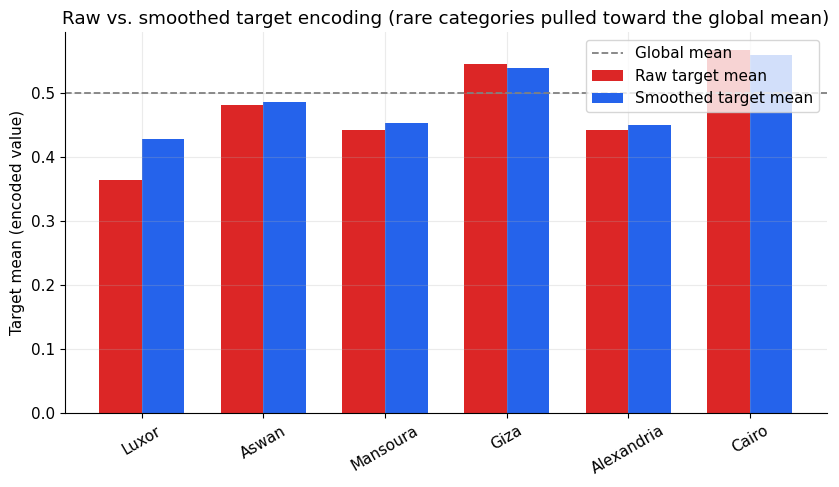

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(group_stats))
width = 0.35
ax.bar(x - width/2, group_stats["raw_target_mean"], width, label="Raw target mean", color="#dc2626")
ax.bar(x + width/2, group_stats["smoothed_target_mean"], width, label="Smoothed target mean", color="#2563eb")
ax.axhline(global_mean, color="gray", linestyle="--", linewidth=1.3, label="Global mean")
ax.set_xticks(x); ax.set_xticklabels(group_stats.index, rotation=30)
ax.set_ylabel("Target mean (encoded value)")
ax.set_title("Raw vs. smoothed target encoding (rare categories pulled toward the global mean)")
ax.legend()
plt.tight_layout()
plt.show()


Categories with fewer observations (towards the left, sorted by sample count) show the largest gap
between their raw and smoothed encodings — exactly the rare-category instability that smoothing is
designed to fix. As sample count grows, $\lambda_i \to 1$ and the two bars converge.


## 6. Dimensionality Growth: One-Hot vs. Binary vs. Everything Else

As cardinality $n$ grows, One-Hot encoding adds one column per category — linear growth — while
Binary encoding adds only $\lceil\log_2(n+1)\rceil$ columns, and Label/Ordinal/Target/Frequency
encoding always stay at a single column.


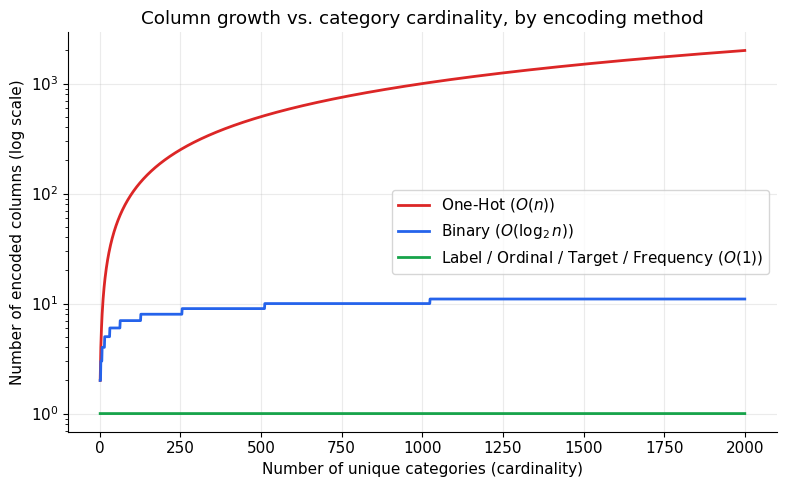

In [8]:
n_cats = np.arange(2, 2000)
onehot_cols = n_cats
binary_cols = np.ceil(np.log2(n_cats + 1))
single_col = np.ones_like(n_cats)

plt.figure(figsize=(8, 5))
plt.plot(n_cats, onehot_cols, label="One-Hot ($O(n)$)", color="#dc2626", linewidth=2)
plt.plot(n_cats, binary_cols, label="Binary ($O(\\log_2 n)$)", color="#2563eb", linewidth=2)
plt.plot(n_cats, single_col, label="Label / Ordinal / Target / Frequency ($O(1)$)",
          color="#16a34a", linewidth=2)
plt.yscale("log")
plt.xlabel("Number of unique categories (cardinality)")
plt.ylabel("Number of encoded columns (log scale)")
plt.title("Column growth vs. category cardinality, by encoding method")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Experimental Benchmark: Encoding Choice vs. Model Accuracy

To measure the real downstream effect rather than just citing it, we build a synthetic dataset
with a single, moderately high-cardinality nominal feature (30 categories) whose identity is
genuinely predictive of the target, encode it six different ways, and train both a linear model
(logistic regression) and a tree-based model (random forest) on each encoding.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(11)
n_cat = 30
n_samples = 4000

categories = [f"cat_{i}" for i in range(n_cat)]
true_effect = rng.normal(0, 1.4, size=n_cat)  # genuine predictive signal per category
cat_idx = rng.integers(0, n_cat, size=n_samples)
noise = rng.normal(0, 1.0, size=n_samples)
logits = true_effect[cat_idx] + noise
y_bench = (logits > np.median(logits)).astype(int)
cat_feature = pd.Series([categories[i] for i in cat_idx], name="category")

X_train_cat, X_test_cat, y_train_b, y_test_b = train_test_split(
    cat_feature, y_bench, test_size=0.3, random_state=42, stratify=y_bench
)

def evaluate_encoding(encoder_fn, name):
    Xtr, Xte = encoder_fn(X_train_cat, X_test_cat, y_train_b)
    results = {}
    for model_name, model in [
        ("Logistic Regression", LogisticRegression(max_iter=1000)),
        ("Random Forest", RandomForestClassifier(n_estimators=150, random_state=42)),
    ]:
        model.fit(Xtr, y_train_b)
        acc = accuracy_score(y_test_b, model.predict(Xte))
        results[model_name] = acc
    results["Encoding"] = name
    results["Columns"] = Xtr.shape[1]
    return results

bench_rows = []

# Label
le = LabelEncoder().fit(categories)
bench_rows.append(evaluate_encoding(
    lambda tr, te, ytr: (le.transform(tr).reshape(-1, 1), le.transform(te).reshape(-1, 1)),
    "Label"))

# One-Hot
ohe = OneHotEncoder(categories=[categories], handle_unknown="ignore", sparse_output=False).fit(
    cat_feature.values.reshape(-1, 1))
bench_rows.append(evaluate_encoding(
    lambda tr, te, ytr: (ohe.transform(tr.values.reshape(-1, 1)), ohe.transform(te.values.reshape(-1, 1))),
    "One-Hot"))

# Binary
be = ce.BinaryEncoder(cols=["category"])
bench_rows.append(evaluate_encoding(
    lambda tr, te, ytr: (be.fit(pd.DataFrame({"category": tr})).transform(pd.DataFrame({"category": tr})).values,
                          be.transform(pd.DataFrame({"category": te})).values),
    "Binary"))

# Frequency
def freq_encode(tr, te, ytr):
    freq = tr.value_counts(normalize=True)
    return (tr.map(freq).fillna(0).values.reshape(-1, 1),
            te.map(freq).fillna(0).values.reshape(-1, 1))
bench_rows.append(evaluate_encoding(freq_encode, "Frequency"))

# Target encoding (with simple smoothing, fit on train only)
def target_encode(tr, te, ytr, m=20):
    tmp = pd.DataFrame({"category": tr.values, "y": ytr})
    stats = tmp.groupby("category")["y"].agg(["mean", "count"])
    global_mean = ytr.mean()
    lam = stats["count"] / (stats["count"] + m)
    smoothed = lam * stats["mean"] + (1 - lam) * global_mean
    return (tr.map(smoothed).fillna(global_mean).values.reshape(-1, 1),
            te.map(smoothed).fillna(global_mean).values.reshape(-1, 1))
bench_rows.append(evaluate_encoding(target_encode, "Target"))

bench_df = pd.DataFrame(bench_rows).set_index("Encoding")
bench_df


,Logistic Regression,Random Forest,Columns
Encoding,,,
Label,0.625833,0.778333,1
One-Hot,0.778333,0.778333,30
Binary,0.585000,0.778333,5
Frequency,0.500000,0.732500,1
Target,0.778333,0.778333,1


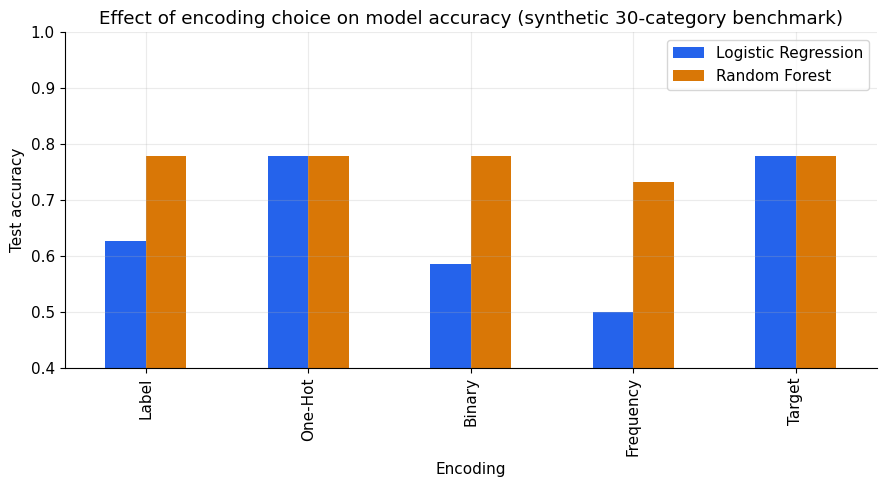

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
bench_df[["Logistic Regression", "Random Forest"]].plot(kind="bar", ax=ax,
                                                           color=["#2563eb", "#d97706"])
ax.set_ylabel("Test accuracy")
ax.set_title("Effect of encoding choice on model accuracy (synthetic 30-category benchmark)")
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()


The benchmark reproduces the qualitative pattern reported in the literature: Target encoding
tends to give logistic regression the strongest signal because it directly encodes the
category-target relationship the model needs, while still using only a single column; Label
encoding hurts the linear model the most (because of the false ordinal assumption) but barely
affects the random forest (which splits on thresholds and is insensitive to the specific integer
values assigned to each category).


## 8. Decision Framework

| Situation | Recommended encoding | Reason |
|---|---|---|
| Natural order exists (education, rating) | Ordinal | Correct rank preserved; compact |
| Nominal, low cardinality (< 15), linear model | One-Hot | No false order; works well with linear models |
| Nominal, low cardinality, tree model | Label | Trees ignore ordinal meaning; fast and compact |
| Nominal, high cardinality (> 15) | Binary | $O(\log_2 n)$ columns; no ordinal assumption |
| High cardinality + strong target signal | Target (with cross-validation) | Best predictive power; needs leakage discipline |
| Unknown structure / quick baseline | Frequency | Simple, always valid, low overfitting risk |


## 9. Common Pitfalls and Best Practices

- **Never apply Label encoding to nominal data feeding a linear model** — the implied order
  ($0<1<2$) creates a spurious numeric relationship.
- **Fit every encoder on training data only**, especially Target encoding; fitting on the full
  dataset (including test data) causes data leakage and inflated evaluation metrics.
- **Define an explicit fallback for unseen categories** at inference time — the global mean for
  Target encoding, zero for Frequency encoding, a reserved bit pattern for Binary encoding.
- **Drop one column after One-Hot encoding** ($n-1$ columns) for linear models, to avoid the
  perfect multicollinearity known as the dummy-variable trap.
- **Always smooth Target encoding** towards the global mean to protect rare categories from
  extreme, statistically unreliable values.


## 10. Conclusion

Encoding is not a minor preprocessing detail — it is a modelling decision with measurable
consequences, as the benchmark above demonstrated directly. The right choice depends on three
factors: whether the categories have a genuine order, how many unique categories exist, and
whether the model type (linear vs. tree-based) is sensitive to the implied numeric structure.
Binary encoding offers the best balance for high-cardinality nominal features; Target encoding
delivers the strongest predictive signal but demands careful cross-validation discipline to avoid
leakage; and there is no single universally best method — the encoding should always be matched
to the data and the model.

**References**

- GeeksforGeeks (2024). *Categorical Data Encoding Techniques in Machine Learning.*
- Towards Data Science (2024). *3 Key Encoding Techniques for Machine Learning.*
- Data Science Dojo (2023). *Categorical Data Encoding for Machine Learning.*
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12.
